In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TOLERANCIA = 1e-9

df = pd.read_csv('resultados.csv')

# **Estatísticas Básicas**

In [25]:
def tabela_relatorio(df):
  resumo = (
      df.groupby('algo')
      .agg(
          gap_media=('gap', 'mean'),
          gap_dp=('gap', 'std'),
          gap_mediana=('gap', 'median'),
          gap_min=('gap', 'min'),
          gap_max=('gap', 'max'),

          tempo_melhor_media=('tempo_melhor', 'mean'),
          tempo_melhor_dp=('tempo_melhor', 'std'),
      )
      .sort_values('gap_media')
  )

  return resumo.round(4)

resumo = tabela_relatorio(df)
display(resumo)
df_resumo = resumo.to_csv('resumo.csv')

,gap_media,gap_dp,gap_mediana,gap_min,gap_max,tempo_melhor_media,tempo_melhor_dp
algo,,,,,,,
vns,0.0072,0.0439,0.0,0.0,0.3451,24.2757,61.4027
ils,0.0083,0.0455,0.0,0.0,0.3805,23.1264,56.0096
ga,0.0247,0.0973,0.0,0.0,0.9643,29.0662,69.4701
lns,0.0379,0.1214,0.0,0.0,1.3104,40.0299,83.4087
brkga,0.0564,0.2023,0.0,0.0,4.4232,43.7584,83.4183
grasp,0.1139,0.3341,0.0,0.0,4.5967,65.8835,105.4766
sa,0.1731,0.4351,0.0,0.0,4.5100,78.9865,112.6954
pso,0.5140,1.1031,0.0,0.0,10.8413,86.9732,111.6158


In [26]:
def percentual_melhor(df):
  melhores = (
      df.groupby(['instancia', 'seed'])['gap']
        .transform('min')
  )

  venceu = df['gap'] == melhores

  ranking = (
      df.assign(venceu=venceu)
        .groupby('algo')['venceu']
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .rename('%_melhor')
  )

  return ranking.round(2)

display(percentual_melhor(df))

,%_melhor
algo,
vns,97.00
ils,96.07
ga,90.80
lns,86.53
brkga,85.27
grasp,73.33
sa,67.33
pso,55.53


In [27]:
def tabela_por_instancia(df):
  resumo = (
      df.groupby(['instancia', 'algo'])
      .agg(
          gap_media=('gap', 'mean'),
          gap_dp=('gap', 'std'),
          gap_mediana=('gap', 'median'),
          gap_min=('gap', 'min'),
          gap_max=('gap', 'max'),

          otimos_encontrados=('gap', lambda x: (x == 0).sum()),
          taxa_otimo=('gap', lambda x: (x == 0).mean() * 100),

          tempo_melhor_media=('tempo_melhor', 'mean'),
          tempo_melhor_dp=('tempo_melhor', 'std'),
      )
      .reset_index()
      .sort_values(['instancia', 'gap_media'])
  )

  return resumo.round(4)

resumo_instancias = tabela_por_instancia(df)
display(resumo_instancias)
df_instancias = resumo_instancias.to_csv('resultados_instacias.csv')

,instancia,algo,gap_media,gap_dp,gap_mediana,gap_min,gap_max,otimos_encontrados,taxa_otimo,tempo_melhor_media,tempo_melhor_dp
0,A-n32-k5,brkga,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0818,0.0049
1,A-n32-k5,ga,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0638,0.0075
2,A-n32-k5,grasp,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0094,0.0063
3,A-n32-k5,ils,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0444,0.0425
4,A-n32-k5,lns,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.1377,0.1266
...,...,...,...,...,...,...,...,...,...,...,...
392,B-n78-k10,brkga,0.0491,0.2157,0.0000,0.0000,1.1466,28,93.3333,115.9609,88.2333
398,B-n78-k10,sa,0.2375,0.1765,0.1638,0.0000,0.5733,4,13.3333,246.5922,99.3220
394,B-n78-k10,grasp,0.3713,0.4661,0.2047,0.0000,1.5561,9,30.0000,231.5095,129.8288
396,B-n78-k10,lns,0.4450,0.3245,0.4095,0.0000,1.3104,2,6.6667,197.6241,126.5429


# **Performance Profile**

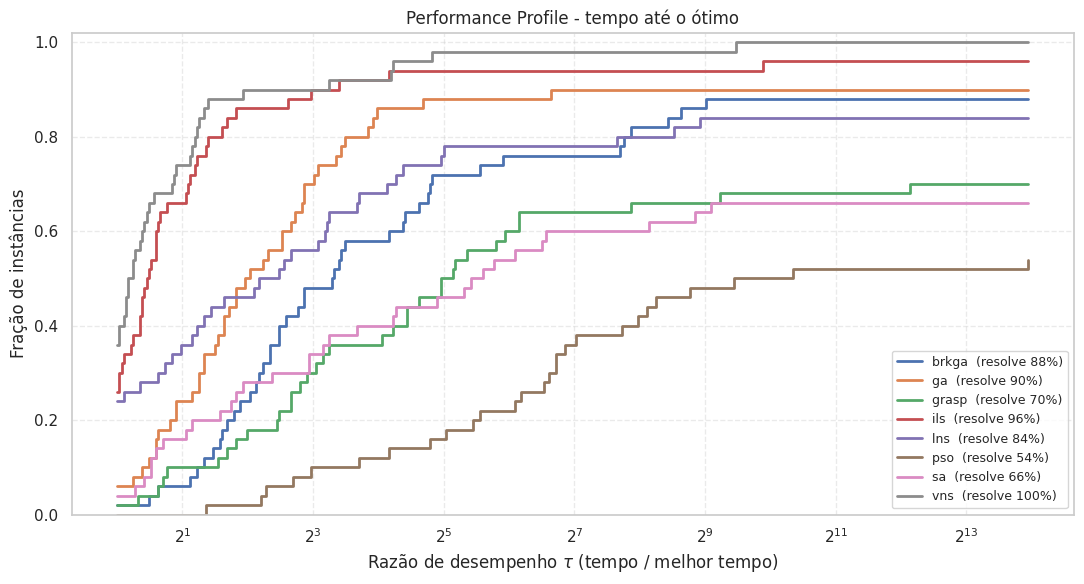

In [28]:
def matriz_tempo_sucesso(df, tolerancia=1e-9, limiar_sucesso=0.5):
  linhas = []
  for (inst, algo), g in df.groupby(['instancia', 'algo']):
      sucesso = g['gap'] <= tolerancia
      taxa = sucesso.mean()

      if sucesso.any():
          tempo_rep = g.loc[sucesso, 'tempo_melhor'].median()
      else:
          tempo_rep = np.nan

      valor = tempo_rep if taxa >= limiar_sucesso else np.inf

      linhas.append({'instancia': inst, 'algo': algo,
                     'taxa_sucesso': taxa, 'valor': valor})

  matriz = (pd.DataFrame(linhas)
            .pivot(index='instancia', columns='algo', values='valor'))
  return matriz

def plot_profile_tempo(matriz, titulo, n_taus=400):
  melhor = matriz.min(axis=1)

  validas = np.isfinite(melhor)
  matriz = matriz[validas]
  melhor = melhor[validas]
  n_inst = len(matriz)

  razao = matriz.divide(melhor, axis=0) # falhas continuam = inf

  max_tau = np.nanmax(razao.replace(np.inf, np.nan).values)
  taus = np.geomspace(1, max_tau, n_taus)

  plt.figure(figsize=(11, 6))
  for algo in sorted(razao.columns):
      r = razao[algo].values
      y = [(r <= t).sum() / n_inst for t in taus]
      plt.step(taus, y, where='post', lw=2,
               label=f'{algo}  (resolve {np.isfinite(r).mean():.0%})')

  plt.xscale('log', base=2)
  plt.xlabel(r'Razão de desempenho $\tau$ (tempo / melhor tempo)')
  plt.ylabel('Fração de instâncias')
  plt.title(titulo)
  plt.grid(True, which='both', ls='--', alpha=0.4)
  plt.legend(loc='lower right', fontsize=9)
  plt.ylim(0, 1.02)
  plt.tight_layout()
  plt.show()
  return razao


matriz_pp_tempo = matriz_tempo_sucesso(df, tolerancia=TOLERANCIA, limiar_sucesso=0.5)
_ = plot_profile_tempo(matriz_pp_tempo, 'Performance Profile - tempo até o ótimo')

# **Time-to-Target**

,seeds,sucessos,taxa_sucesso,ttt_mediano,ttt_min
algo,,,,,
ils,100,100,100.0,36.967,1.306
vns,100,99,99.0,47.163,0.922
ga,100,70,70.0,80.907,17.952
brkga,100,43,43.0,119.427,31.624
lns,100,16,16.0,113.920,23.636
grasp,100,2,2.0,200.461,117.162
sa,100,1,1.0,101.154,101.154
pso,100,0,0.0,NaN,NaN


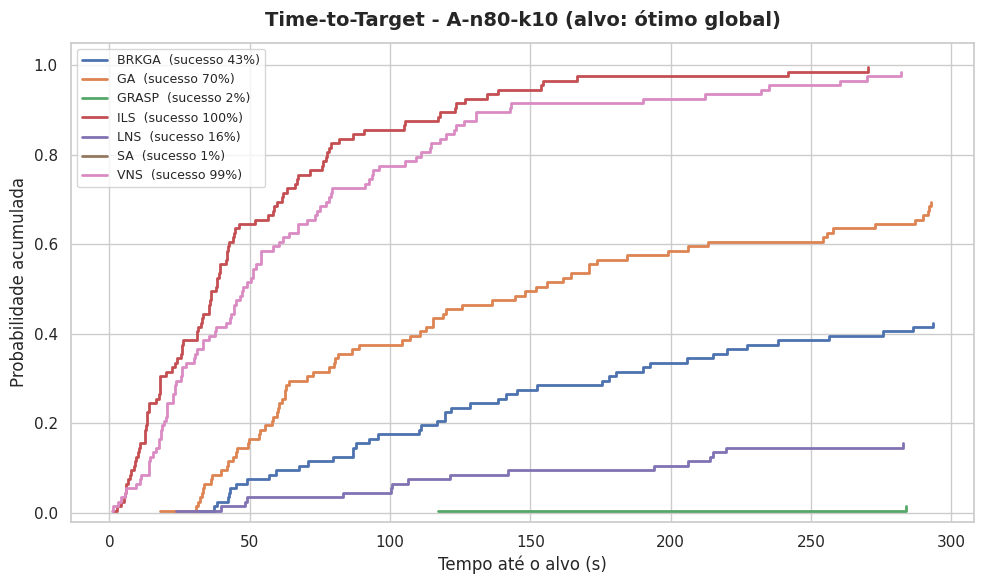

In [42]:
df_ttt = pd.read_csv('A-n80-k10.csv')

INSTANCIA_TTT = 'A-n80-k10'
ESCALA_LOG = False

def curvas_ttt_instancia(df_ttt, instancia, tolerancia=1e-9):
  sub = df_ttt[df_ttt['instancia'] == instancia].copy()
  if sub.empty:
      raise ValueError(f'Instância {instancia!r} não encontrada.')

  sub['atingiu'] = sub['gap'] <= tolerancia
  linhas = []
  for algo, g in sub.groupby('algo'):
      N = len(g) # seeds
      tempos = np.sort(g.loc[g['atingiu'], 'tempo_melhor'].values)
      for i, t in enumerate(tempos, start=1):
          linhas.append({'algo': algo, 'tempo': t,
                         'prob': (i - 0.5) / N, 'N': N})
  return pd.DataFrame(linhas)

def resumo_ttt_instancia(df_ttt, instancia, tolerancia=1e-9):
  sub = df_ttt[df_ttt['instancia'] == instancia].copy()
  sub['atingiu'] = sub['gap'] <= tolerancia
  ttt = sub.loc[sub['atingiu'], 'tempo_melhor']
  return (sub.groupby('algo').agg(seeds=('seed', 'nunique'), sucessos=('atingiu', 'sum'), taxa_sucesso=('atingiu', lambda x: 100 * x.mean()),
                 ttt_mediano=('tempo_melhor',
                              lambda x: x[sub.loc[x.index, 'atingiu']].median()),
                 ttt_min=('tempo_melhor',
                          lambda x: x[sub.loc[x.index, 'atingiu']].min()))
            .sort_values(['taxa_sucesso', 'ttt_mediano'],
                         ascending=[False, True])
            .round(3))


def plot_ttt(curvas, instancia, escala_log=False):
  sns.set_theme(style='whitegrid')
  plt.figure(figsize=(10, 6))
  for algo in sorted(curvas['algo'].unique()):
      d = curvas[curvas['algo'] == algo]
      if d.empty:
          continue
      teto = d['prob'].max() + 0.5 / d['N'].iloc[0]
      plt.plot(d['tempo'], d['prob'], drawstyle='steps-post', lw=2,
               label=f'{algo.upper()}  (sucesso {teto:.0%})')

  if escala_log:
      plt.xscale('log')
      plt.xlabel('Tempo até o alvo (s, escala log)', fontsize=12)
  else:
      plt.xlabel('Tempo até o alvo (s)', fontsize=12)

  plt.ylabel('Probabilidade acumulada', fontsize=12)
  plt.title(f'Time-to-Target - {instancia} (alvo: ótimo global)',
            fontsize=14, fontweight='bold', pad=12)
  plt.ylim(-0.02, 1.05)
  plt.legend(title='', fontsize=9, title_fontsize=10,
             loc='upper left')
  plt.tight_layout()
  plt.show()


display(resumo_ttt_instancia(df_ttt, INSTANCIA_TTT, TOLERANCIA))
curvas = curvas_ttt_instancia(df_ttt, INSTANCIA_TTT, TOLERANCIA)
plot_ttt(curvas, INSTANCIA_TTT, escala_log=ESCALA_LOG)

# **Teste de Friedman**

In [30]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon

def preparar_matriz_teste(df, metrica, agregacao='mean', nivel='instancia'):
  df = df.copy()

  df.columns = df.columns.str.strip()
  df['instancia'] = df['instancia'].astype(str).str.strip()
  df['algo'] = df['algo'].astype(str).str.strip()

  df[metrica] = pd.to_numeric(df[metrica], errors='coerce')

  if nivel == 'instancia':
      index_cols = ['instancia']
      group_cols = ['instancia', 'algo']

  elif nivel == 'instancia_seed':
      index_cols = ['instancia', 'seed']
      group_cols = ['instancia', 'seed', 'algo']

  else:
      raise ValueError("nivel deve ser 'instancia' ou 'instancia_seed'.")

  df_agg = (
      df.groupby(group_cols)
        .agg(valor=(metrica, agregacao))
        .reset_index()
  )

  matriz = df_agg.pivot(
      index=index_cols,
      columns='algo',
      values='valor'
  )

  matriz = matriz.dropna()

  return matriz

In [31]:
def teste_friedman(df, metrica, agregacao='mean', nivel='instancia'):
  matriz = preparar_matriz_teste(
      df,
      metrica=metrica,
      agregacao=agregacao,
      nivel=nivel
  )

  algoritmos = list(matriz.columns)

  dados_por_algoritmo = [
      matriz[algo].values
      for algo in algoritmos
  ]

  stat, p_valor = friedmanchisquare(*dados_por_algoritmo)

  rankings = matriz.rank(axis=1, ascending=True, method='average')

  rankings_medios = (
      rankings.mean()
      .reset_index()
  )

  rankings_medios.columns = [
      'algo',
      'ranking_medio'
  ]

  rankings_medios = rankings_medios.sort_values(
      by='ranking_medio'
  ).reset_index(drop=True)

  resumo = pd.DataFrame([{
      'metrica': metrica,
      'agregacao': agregacao,
      'nivel': nivel,
      'n_blocos': matriz.shape[0],
      'n_algoritmos': matriz.shape[1],
      'estatistica_friedman': stat,
      'p_valor': p_valor,
      'significativo_5%': p_valor < 0.05
  }])

  return resumo, rankings_medios, matriz

In [32]:
friedman_gap, ranking_gap, matriz_gap = teste_friedman(
  df,
  metrica='gap',
  agregacao='mean',
  nivel='instancia'
)

display(friedman_gap)
display(ranking_gap)

,metrica,agregacao,nivel,n_blocos,n_algoritmos,estatistica_friedman,p_valor,significativo_5%
0,gap,mean,instancia,50,8,125.289971,6.048737e-24,True


,algo,ranking_medio
0,ils,3.53
1,vns,3.61
2,ga,3.82
3,lns,4.04
4,brkga,4.47
5,grasp,4.93
6,sa,5.43
7,pso,6.17


In [33]:
friedman_tempo_melhor, ranking_tempo_melhor, matriz_tempo_melhor = teste_friedman(
    df,
    metrica='tempo_melhor',
    agregacao='mean',
    nivel='instancia'
)

display(friedman_tempo_melhor)
display(ranking_tempo_melhor)

,metrica,agregacao,nivel,n_blocos,n_algoritmos,estatistica_friedman,p_valor,significativo_5%
0,tempo_melhor,mean,instancia,50,8,168.793333,4.509533e-33,True


,algo,ranking_medio
0,vns,2.42
1,ils,2.62
2,ga,3.30
3,lns,4.08
4,brkga,4.86
5,grasp,5.68
6,sa,5.78
7,pso,7.26


# **Teste de Wilcoxon**

In [34]:
def preparar_matriz_wilcoxon(df, metrica, agregacao='mean'):
  df = df.copy()

  df.columns = df.columns.str.strip()
  df['instancia'] = df['instancia'].astype(str).str.strip()
  df['algo'] = df['algo'].astype(str).str.strip()
  df[metrica] = pd.to_numeric(df[metrica], errors='coerce')

  df_agg = (
      df.groupby(['instancia', 'algo'])
        .agg(valor=(metrica, agregacao))
        .reset_index()
  )

  matriz = df_agg.pivot(
      index='instancia',
      columns='algo',
      values='valor'
  )

  matriz = matriz.dropna()

  return matriz

In [35]:
def teste_wilcoxon_completo(df, metrica, agregacao='mean', alpha=0.05):
  matriz = preparar_matriz_wilcoxon(df=df, metrica=metrica, agregacao=agregacao)
  algoritmos = list(matriz.columns)
  resultados = []

  for algo_a, algo_b in itertools.combinations(algoritmos, 2):
      v_a = matriz[algo_a].values
      v_b = matriz[algo_b].values

      wins_a = np.sum(v_a < v_b)
      wins_b = np.sum(v_b < v_a)
      empates = np.sum(v_a == v_b)

      try:
          _, p_valor = wilcoxon(v_a, v_b, alternative='two-sided', zero_method='wilcox')
      except ValueError:
          p_valor = 1.0

      sig = p_valor < alpha

      if sig:
          m_a, m_b = np.mean(v_a), np.mean(v_b)
          melhor = algo_a if m_a < m_b else algo_b
          veredito = f'{melhor} é superior'
      else:
          melhor = 'Empate'
          veredito = 'Equivalentes'

      resultados.append({
          'Comparação': f'{algo_a} vs {algo_b}',
          'Vitórias A': wins_a,
          'Vitórias B': wins_b,
          'Empates': empates,
          'p-valor': round(p_valor, 8),
          'Significativo?': 'Sim' if sig else 'Não',
          'Melhor': melhor
      })

  resultado_df = pd.DataFrame(resultados)
  return resultado_df, matriz

In [36]:
wilcoxon_gap, matriz_gap = teste_wilcoxon_completo(
  df,
  metrica='gap',
  agregacao='mean'
)

display(wilcoxon_gap)

,Comparação,Vitórias A,Vitórias B,Empates,p-valor,Significativo?,Melhor
0,brkga vs ga,2,16,32,0.001847,Sim,ga
1,brkga vs grasp,16,4,30,0.008968,Sim,brkga
2,brkga vs ils,1,17,32,0.000863,Sim,ils
3,brkga vs lns,6,12,32,0.156955,Não,Empate
4,brkga vs pso,24,0,26,0.000018,Sim,brkga
5,brkga vs sa,20,2,28,0.000091,Sim,brkga
6,brkga vs vns,2,17,31,0.000625,Sim,vns
7,ga vs grasp,19,1,30,0.000593,Sim,ga
8,ga vs ils,0,8,42,0.011719,Sim,ils
9,ga vs lns,9,4,37,0.382352,Não,Empate


In [37]:
wilcoxon_tempo_melhor, matriz_tempo_melhor = teste_wilcoxon_completo(
  df,
  metrica='tempo_melhor',
  agregacao='mean'
)

display(wilcoxon_tempo_melhor)

,Comparação,Vitórias A,Vitórias B,Empates,p-valor,Significativo?,Melhor
0,brkga vs ga,6,44,0,1.400000e-07,Sim,ga
1,brkga vs grasp,34,16,0,2.857000e-04,Sim,brkga
2,brkga vs ils,9,41,0,9.469000e-05,Sim,ils
3,brkga vs lns,20,30,0,4.547880e-01,Não,Empate
4,brkga vs pso,45,5,0,0.000000e+00,Sim,brkga
5,brkga vs sa,35,15,0,7.700000e-07,Sim,brkga
6,brkga vs vns,8,42,0,7.501000e-05,Sim,vns
7,ga vs grasp,42,8,0,1.000000e-08,Sim,ga
8,ga vs ils,15,35,0,4.610039e-02,Sim,ils
9,ga vs lns,35,15,0,1.025120e-03,Sim,ga


In [38]:
wilcoxon_gap.to_csv(
  'wilcoxon_gap_medio.csv',
  index=False,
  sep=';',
  encoding='utf-8-sig'
)

wilcoxon_tempo_melhor.to_csv(
  'wilcoxon_tempo_melhor_medio.csv',
  index=False,
  sep=';',
  encoding='utf-8-sig'
)